# Pipeline

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import shap

# source ~/melanoma_env/bin/activate

/home/sbodin/melanoma_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# DATA
df_sanger = pd.read_csv('data/Dataset_sanger.csv')
df_responder = pd.read_csv('data/Dataset_sanger_3g.csv')

# Merge sur les clefs
merge_cols = ['SANGER_MODEL_ID']
col_to_keep = merge_cols + ['DRUG_NAME', 'DRUG_ID', 'BRAF_Mut', 'is_responder']
df_50AUC = pd.merge(df_sanger, df_responder[col_to_keep], on=merge_cols, how='inner')


print(f"Shape APRES merge (avant nettoyage): {df_50AUC.shape}")

seuil_na = len(df_50AUC) * 0.90 
df_50AUC = df_50AUC.dropna(axis=1, thresh=seuil_na)

num_cols = df_50AUC.select_dtypes(include=[np.number]).columns
df_50AUC[num_cols] = df_50AUC[num_cols].fillna(df_50AUC[num_cols].median())

df_50AUC = df_50AUC.dropna(subset=['is_responder', 'BRAF_Mut'])

print(f"Shape final prêt pour l'analyse: {df_50AUC.shape}")
#print(df_50AUC.head())

# 2. Extraction features
meta_cols = ['SANGER_MODEL_ID', 'DRUG_NAME', 'DRUG_ID', 'BRAF_Mut', 'is_responder', 'model_name', 'data_source']
genes_columns = [c for c in df_50AUC.columns if c not in meta_cols]
X_genes = df_50AUC[genes_columns]

# Variance Threshold
selector_var = VarianceThreshold(threshold=0.8)
X_reduced = pd.DataFrame(
    selector_var.fit_transform(X_genes),
    columns=X_genes.columns[selector_var.get_support()],
    index=df_50AUC.index
)

X_final = X_reduced.copy()
X_final['BRAF_Mut'] = df_50AUC['BRAF_Mut'].values
X_final = X_final.dropna(axis=1)

print(f"X_final est prêt avec {X_final.shape[1]} features.")


def run_per_drug_pipeline_with_fs(data_df, features_df, output_name):
    model_dir = f"models_{output_name}"
    os.makedirs(model_dir, exist_ok=True)

    drugs = data_df['DRUG_NAME'].unique()
    results = []

    for drug in drugs:
        mask = data_df['DRUG_NAME'] == drug
        y_drug = data_df.loc[mask, 'is_responder']
        X_drug_full = features_df.loc[mask].dropna(axis=1)
        
        n_pos = sum(y_drug)
        if n_pos < 5: 
            continue

        ratio = (len(y_drug) - n_pos) / n_pos
        k = min(50, X_drug_full.shape[1])

        # Pipeline
        pipeline = Pipeline([
            ('zero_var_filter', VarianceThreshold(threshold=0.0)),
            ('selector', SelectKBest(score_func=f_classif, k=k)),
            ('xgb', XGBClassifier(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.05,
                scale_pos_weight=ratio,
                tree_method='hist',
                random_state=24
            ))
        ])

        cv_splits = min(5, n_pos)
        skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=24)

        custom_scoring = {
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score, zero_division=0),
            'f1': make_scorer(f1_score, zero_division=0)
        }
        
        try:
            cv_results = cross_validate(
                pipeline, X_drug_full, y_drug, 
                cv=skf, scoring=custom_scoring
            )

            pipeline.fit(X_drug_full, y_drug)
            
            fitted_selector = pipeline.named_steps['selector']
            support_mask = fitted_selector.get_support()
            
            selected_genes = X_drug_full.columns[support_mask]
            f_scores = fitted_selector.scores_[support_mask]
            
            # F-score decroissant
            sorted_indices = np.argsort(f_scores)[::-1]
            top_genes_sorted = selected_genes[sorted_indices]
            top_f_scores = f_scores[sorted_indices]

            # SAuvegarde
            model_data = {
                'model': pipeline.named_steps['xgb'], 
                'selected_features': top_genes_sorted.tolist()
            }
            
            # Nettoyer le nom de la drogue pour le path
            safe_drug_name = str(drug).replace(' ', '_').replace('/', '_')
            model_filename = os.path.join(model_dir, f"{safe_drug_name}.joblib")
            joblib.dump(model_data, model_filename)

            results.append({
                'Drug': drug,
                'Positive_Cases': n_pos,
                'Precision': np.mean(cv_results['test_precision']),
                'Recall': np.mean(cv_results['test_recall']),
                'F1_Score': np.mean(cv_results['test_f1']),
                'Top_Gene': top_genes_sorted[0],
                'F_scores': top_f_scores[0],
                'Model_Path': model_filename
            })
        except Exception as e:
            print(f"Erreur sur {drug}: {e}")

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(by='F1_Score', ascending=False)
        results_df.to_excel(f"results_{output_name}_with_FS.xlsx", index=False)
    
    return results_df

print("Pipeline prete")

Shape APRES merge (avant nettoyage): (23758, 36360)
Shape final prêt pour l'analyse: (23758, 31792)
X_final est prêt avec 3954 features.
Pipeline prete


### Run model

In [3]:
run_per_drug_pipeline_with_fs(df_50AUC, X_final, "test3")

/home/sbodin/melanoma_env/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Erreur sur HG-6-71-01: boolean index did not match indexed array along axis 0; size of axis is 3954 but size of corresponding boolean axis is 3951


/home/sbodin/melanoma_env/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Erreur sur torin2: boolean index did not match indexed array along axis 0; size of axis is 3954 but size of corresponding boolean axis is 3951


/home/sbodin/melanoma_env/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/sbodin/melanoma_env/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Erreur sur THZ-1-87: boolean index did not match indexed array along axis 0; size of axis is 3954 but size of corresponding boolean axis is 3950


,Drug,Positive_Cases,Precision,Recall,F1_Score,Top_Gene,F_scores,Model_Path
366,Dihydrorotenone,9,1.000000,0.900000,0.933333,GPR161,43.688641,models_test3/Dihydrorotenone.joblib
374,WYE-125132,32,0.900000,0.900000,0.891979,IFI16,14.977410,models_test3/WYE-125132.joblib
462,Saracatinib,6,0.800000,0.800000,0.800000,ANO5,27.570064,models_test3/Saracatinib.joblib
457,CGP-60474,9,0.833333,0.800000,0.760000,HS3ST3A1,41.228809,models_test3/CGP-60474.joblib
138,NVP-ADW742,31,0.706349,0.809524,0.750549,RDH5,18.810335,models_test3/NVP-ADW742.joblib
...,...,...,...,...,...,...,...,...
76,Tretinoin,12,0.000000,0.000000,0.000000,IER5,15.862904,models_test3/Tretinoin.joblib
44,IAP_7638,9,0.000000,0.000000,0.000000,NPB,15.738273,models_test3/IAP_7638.joblib
420,Vismodegib,5,0.000000,0.000000,0.000000,NPIPA2,15.441060,models_test3/Vismodegib.joblib
440,Erlotinib,14,0.000000,0.000000,0.000000,PLK2,11.297276,models_test3/Erlotinib.joblib


### Trametinib

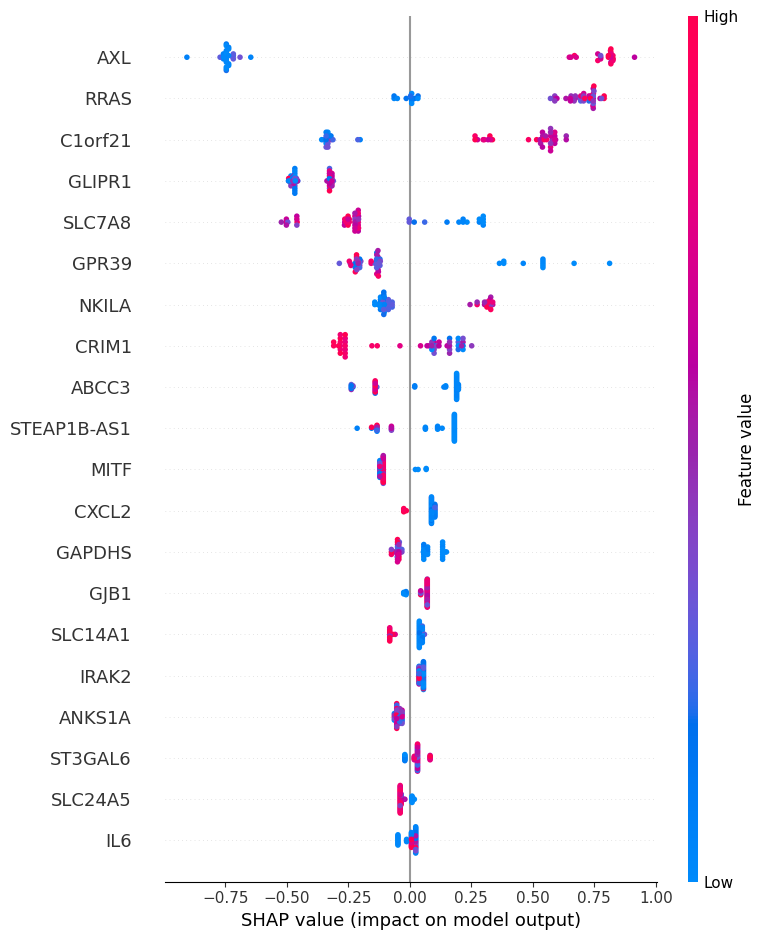

In [ ]:
# Trametinib
model_Trametinib = joblib.load("Explained_models/Trametinib.joblib")
xgb_model_Trametinib = model_Trametinib['model']
selected_genes_Trametinib = model_Trametinib['selected_features']

#Mask
mask_Trametinib = df_50AUC['DRUG_NAME'] == 'Trametinib'
y_drug = df_50AUC.loc[mask_Trametinib, 'is_responder']
X_drug = X_final.loc[mask_Trametinib, selected_genes_Trametinib]

explainer = shap.TreeExplainer(xgb_model_Trametinib)
shap_values_Trametinib = explainer.shap_values(X_drug)

shap.summary_plot(shap_values_Trametinib, X_drug, max_display=20)

shap_matrix_Trametinib = shap_values_Trametinib

In [5]:
print(f"Nombre de gènes stockés : {len(selected_genes_Trametinib)}")
print("Top 5 des gènes :", selected_genes_Trametinib[:5])

Nombre de gènes stockés : 50
Top 5 des gènes : ['NRROS', 'CRIM1-DT', 'RRAS', 'IL6', 'IL7R']


### Dabrafenib

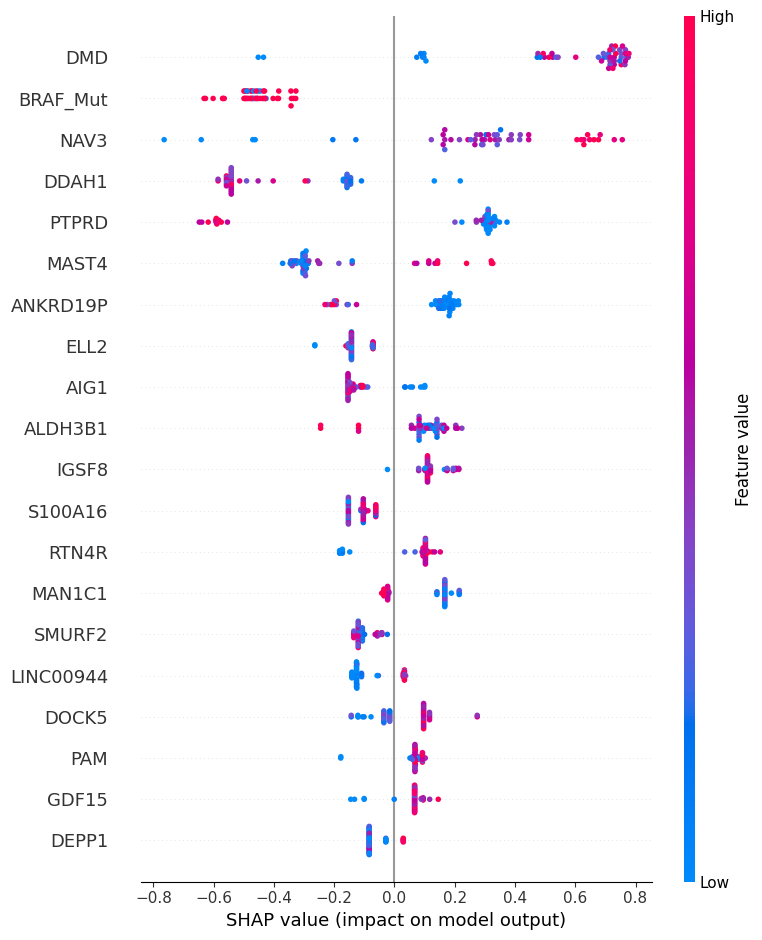

In [ ]:
model_Dabrafenib = joblib.load("Explained_models/Dabrafenib.joblib")
xgb_model_Dabrafenib = model_Dabrafenib['model']
selected_genes_Dabrafenib = model_Dabrafenib['selected_features']

#Mask
mask_dabrafenib = df_50AUC['DRUG_NAME'] == 'Dabrafenib'
y_drug = df_50AUC.loc[mask_dabrafenib, 'is_responder']
X_drug = X_final.loc[mask_dabrafenib, selected_genes_Dabrafenib]

explainer = shap.TreeExplainer(xgb_model_Dabrafenib)
shap_values_Dabrafenib = explainer.shap_values(X_drug)

shap.summary_plot(shap_values_Dabrafenib, X_drug, max_display=20)

In [7]:
print(f"Nombre de gènes stockés : {len(selected_genes_Dabrafenib)}")
print("Top 5 des gènes :", selected_genes_Dabrafenib[:5])

Nombre de gènes stockés : 50
Top 5 des gènes : ['ELL2', 'ALDH3B1', 'LINGO1', 'CPA2', 'DOCK5']
